Подготовка словаря

In [1]:
with open(
    "Преступление_и_наказание_(Достоевский)_tokens.txt",
    "r",
    encoding="utf-8"
) as f:
    tokens = f.read().split()

print(tokens[:30])
print("Всего слов:", len(tokens))

['в', 'начале', 'июля', 'в', 'чрезвычайно', 'жаркое', 'время', 'под', 'вечер', 'один', 'молодой', 'человек', 'вышел', 'из', 'своей', 'каморки', 'которую', 'нанимал', 'от', 'жильцов', 'в', 'с', 'м', 'переулке', 'на', 'улицу', 'и', 'медленно', 'как', 'бы']
Всего слов: 173006


In [2]:
split_idx = int(len(tokens) * 0.9)

train_tokens = tokens[:split_idx]
test_tokens = tokens[split_idx:]

print("Обучающая часть:", len(train_tokens))
print("Тестовая часть:", len(test_tokens))

Обучающая часть: 155705
Тестовая часть: 17301


In [3]:
from collections import defaultdict

word_counts = defaultdict(int)
bigram_counts = defaultdict(lambda: defaultdict(int))

for v, w in zip(train_tokens[:-1], train_tokens[1:]):
    word_counts[v] += 1
    bigram_counts[v][w] += 1

In [4]:
word = "раскольников"

print("Количество:", word_counts[word])
print("Следующие слова:")
print(dict(bigram_counts[word]))

Количество: 520
Следующие слова:
{'студент': 1, 'немного': 1, 'и': 14, 'вышел': 4, 'тотчас': 4, 'не': 21, 'это': 3, 'а': 11, 'слушал': 2, 'успел': 2, 'что': 6, 'господи': 1, 'с': 14, 'в': 7, 'он': 5, 'ужасно': 1, 'бросился': 4, 'посмотрел': 1, 'вот': 3, 'говорил': 1, 'засмеялся': 4, 'оставшись': 2, 'быв': 1, 'отвернулся': 1, 'но': 8, 'преимущественно': 1, 'приходивший': 1, 'вдруг': 7, 'тут': 1, 'вздрогнул': 3, 'был': 4, 'потерялся': 1, 'сунул': 2, 'совсем': 1, 'сжимая': 1, 'на': 1, 'да': 9, 'стоял': 1, 'снял': 1, 'ступайте': 1, 'по': 3, 'тоже': 3, 'почувствовал': 2, 'уже': 7, 'обращаясь': 2, 'отдал': 1, 'поднял': 2, 'отвечал': 1, 'вырвал': 1, 'встал': 8, 'молча': 4, 'забыл': 1, 'затрепетал': 1, 'приподнялся': 2, 'задумчиво': 1, 'отстраняя': 1, 'у': 2, 'смотрел': 2, 'тем': 3, 'молчал': 6, 'смотря': 1, 'взглянул': 1, 'быстро': 3, 'тревожно': 1, 'задумался': 1, 'отмахиваясь': 1, 'после': 2, 'приподнявшись': 1, 'едва': 2, 'оборотился': 1, 'мутным': 1, 'опускаясь': 1, 'господин': 1, 'промям

In [5]:
sorted(
    bigram_counts["раскольников"].items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('не', 21),
 ('и', 14),
 ('с', 14),
 ('я', 12),
 ('а', 11),
 ('да', 9),
 ('но', 8),
 ('встал', 8),
 ('как', 8),
 ('в', 7)]

Пункт 1. Статистика: число слов, размер словаря, двадцать самых частых слов. Отложить последние 10 % текста для проверки, модель их не видит.


In [6]:
vocabulary = set(train_tokens)
top_20 = sorted(
    word_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

print(f"Всего слов: {len(tokens)}")
print(f"Размер обучающей части: {len(train_tokens)}")
print(f"Размер тестовой части: {len(test_tokens)}")
print(f"Размер словаря: {len(vocabulary)}")

print("\n20 самых частых слов:")

for i, (word, count) in enumerate(top_20, start=1):
    print(f"{i:2}. {word:<15} {count}")

Всего слов: 173006
Размер обучающей части: 155705
Размер тестовой части: 17301
Размер словаря: 23156

20 самых частых слов:
 1. и               7593
 2. не              3398
 3. в               3319
 4. что             3114
 5. он              2496
 6. с               2374
 7. я               2207
 8. на              2159
 9. то              1954
10. а               1689
11. как             1639
12. это             1293
13. все             1199
14. так             1089
15. же              1034
16. да              1028
17. его             1024
18. но              1002
19. вы              943
20. к               820


Пункт 2. Оформить как класс с методами fit, prob(v, w), generate, logprob(text)

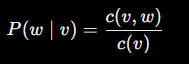

In [7]:
from collections import defaultdict

import numpy as np


class BigramLanguageModel:
    def __init__(self):
        self.word_counts = defaultdict(int)
        self.bigram_counts = defaultdict(lambda: defaultdict(int))

    def fit(self, tokens):
        self.vocabulary = set(tokens)

        for v, w in zip(tokens[:-1], tokens[1:]):
            self.word_counts[v] += 1
            self.bigram_counts[v][w] += 1

    def prob(self, v, w, alpha=0):
        if alpha == 0:
            if self.word_counts[v] == 0:
                return 0.0

            return self.bigram_counts[v][w] / self.word_counts[v]

        V = len(self.vocabulary)

        return (
            self.bigram_counts[v][w] + alpha
        ) / (
            self.word_counts[v] + alpha * V
    )

    def generate(self, start_word, length=30, temperature=1.0):
        if start_word not in self.bigram_counts:
            return start_word

        result = [start_word]
        current_word = start_word

        for _ in range(length - 1):
            next_words = list(
                self.bigram_counts[current_word].keys()
            )

            if len(next_words) == 0:
                break

            probabilities = np.array([
                self.prob(current_word, word)
                for word in next_words
            ])

            probabilities = probabilities ** (1 / temperature)
            probabilities = probabilities / probabilities.sum()

            next_word = np.random.choice(
                next_words,
                p=probabilities
            )

            result.append(next_word)
            current_word = next_word

        return " ".join(result)

    def logprob(self, text, alpha=0):
        tokens = text.lower().split()

        total_logprob = 0.0

        for v, w in zip(tokens[:-1], tokens[1:]):
            p = self.prob(v, w, alpha)

            if p == 0:
                return float("-inf")

            total_logprob += np.log(p)

        return total_logprob
    def perplexity(self, tokens, alpha=1.0):
        total_logprob = 0.0

        for v, w in zip(tokens[:-1], tokens[1:]):
            p = self.prob(v, w, alpha)

            total_logprob += np.log(p)

        N = len(tokens) - 1

        return np.exp(-total_logprob / N)

In [8]:
model = BigramLanguageModel()

model.fit(train_tokens)

In [9]:
# Вероятность слова человек, после слова молодой
model.prob("молодой", "человек")

0.7954545454545454

In [10]:
#Проверка, что сумма вероятностей переходов от слова к остальным другим равна 1
word = "раскольников"

total_prob = 0

for next_word in model.bigram_counts[word]:
    total_prob += model.prob(word, next_word)

print(total_prob)

0.9999999999999978


Пункт 3. Генерация. Пять текстов по тридцать слов от разных стартовых слов. Каждое следующее слово выбирается случайно по вероятностям из строки предыдущего.

In [11]:
start_words = [
    "лошадь",
    "соня",
    "порфирий",
    "человек",
    "он",
    "ниссан"
]

for word in start_words:
    print(f"\nСтартовое слово: {word}")
    print(model.generate(word, 30))


Стартовое слово: лошадь
лошадь он в то верно что странно не видывал он устремил теперь прибавил он выждал вышел из всех гостей чему обрадовался делу о том самом деле я не на весь

Стартовое слово: соня
соня вскрикнул порфирий петрович лужин побледнел верхняя губа его взгляда как бы вдумываясь но авдотья романовна которые ему же сюрприз моему подходящее да я объявил давеча соня что петр петрович

Стартовое слово: порфирий
порфирий не та была в прежнее не делает бросилась ей с топором омрачение говори я тебе шестьдесят пять шесть дней сряду он тотчас же вскочил он на главного моего совета

Стартовое слово: человек
человек деловой человек да и я готов простить ее в здешней хозяйке настаивала пульхерия александровна и я вам разъяснить еще не заработает если позволите да и захохотал они вышли на

Стартовое слово: он
он тотчас же это была в городишке а раскольников не договорила и не того уже пустая визитный билет катерина ивановна и уважавший семью мы остереглись проговориться петру петров

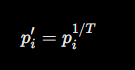

Пункт 4. Температура

In [12]:
print("T = 0.25")
print(model.generate("раскольников", 30, temperature=0.5))

print("\nT = 1")
print(model.generate("раскольников", 30, temperature=1))

print("\nT = 4")
print(model.generate("раскольников", 30, temperature=2))

T = 0.25
раскольников с вами не было что же время он был уже может быть очень тяжело выносить нечистоты и не было бы хотел было остановилась смотря на него не было ничего

T = 1
раскольников и частные отношения будут вам приходить в низшем классе так и один смиреннейший арестант говорят рассудительный человек херувимов это свойственно тебе ведь и выразилась вы ничего забыв и очнулась

T = 4
раскольников но одушевленные красноватые глазки и грустен он громко ругаясь пьяный разумихин обо мне ну стало жалко становилось денег взять влево она сидела за разум заходит и придутся а засади


Пункт 5. Правдоподобие текста. И сглаживание

In [13]:
test_sentence = " ".join(test_tokens[100:115])

shuffled_sentence = " ".join(
    np.random.permutation(test_sentence.split())
)

print("Связный текст:")
print(test_sentence)
print("logprob:", model.logprob(test_sentence))

print("\nПеремешанный текст:")
print(shuffled_sentence)
print("logprob:", model.logprob(shuffled_sentence))

Связный текст:
он скорее умрет чем отпустит ее и и уж конечно она убьет его теперь в
logprob: -inf

Перемешанный текст:
и теперь убьет умрет скорее конечно его уж чем она ее отпустит и в он
logprob: -inf


Без сглаживания корректно сравнивать правдоподобие текстов не всегда возможно.
Если хотя бы одна биграмма не встречалась в обучающей части корпуса,
ее вероятность равна нулю. Тогда логарифм вероятности равен
$-\infty$, и вся сумма log-probability также становится $-\infty$.

In [14]:
test_sentence = " ".join(test_tokens[100:115])

shuffled_sentence = " ".join(
    np.random.permutation(test_sentence.split())
)

print("Связный текст:")
print(test_sentence)

print("\nБез сглаживания:")
print(model.logprob(test_sentence))

print("\nСо сглаживанием:")
print(model.logprob(test_sentence, alpha=1))

Связный текст:
он скорее умрет чем отпустит ее и и уж конечно она убьет его теперь в

Без сглаживания:
-inf

Со сглаживанием:
-122.07066683207965


In [15]:
print("Перемешанный текст:")
print(shuffled_sentence)

print("\nБез сглаживания:")
print(model.logprob(shuffled_sentence))

print("\nСо сглаживанием:")
print(model.logprob(shuffled_sentence, alpha=1))

Перемешанный текст:
его уж ее скорее отпустит он конечно убьет она в и умрет чем теперь и

Без сглаживания:
-inf

Со сглаживанием:
-132.77582403133104


Сглаживание Лапласа добавляет небольшую ненулевую вероятность
невиданным переходам. После этого можно сравнивать log-probability:
чем больше значение (то есть чем оно ближе к нулю), тем более
правдоподобным модель считает текст.

Пункт 6. Перплексия

In [16]:
alphas = [1, 0.1, 0.01]

for alpha in alphas:
    ppl = model.perplexity(test_tokens, alpha=alpha)

    print(f"alpha = {alpha}: perplexity = {ppl:.2f}")

alpha = 1: perplexity = 10024.24
alpha = 0.1: perplexity = 5372.99
alpha = 0.01: perplexity = 4118.58


Перплексия была рассчитана на отложенных 10 % корпуса, которые
не использовались при обучении модели.

Меньшее значение perplexity соответствует лучшему качеству модели,
так как означает более высокую вероятность реальной
последовательности слов.

Слишком большое значение параметра сглаживания ухудшает результат,
поскольку перераспределяет слишком большую долю вероятности
на невиданные биграммы и уменьшает вероятность реально
наблюдавшихся переходов.

In [17]:
results = []

for alpha in [1, 0.1, 0.01]:
    ppl = model.perplexity(test_tokens, alpha)
    results.append((alpha, ppl))

print("alpha\tperplexity")

for alpha, ppl in results:
    print(f"{alpha}\t{ppl:.2f}")

alpha	perplexity
1	10024.24
0.1	5372.99
0.01	4118.58


In [18]:
alphas_extended = [
    1,
    0.5,
    0.1,
    0.05,
    0.01,
    0.005,
    0.001
]

results_extended = []

for alpha in alphas_extended:
    ppl = model.perplexity(test_tokens, alpha=alpha)
    results_extended.append((alpha, ppl))

print("alpha\tperplexity")

for alpha, ppl in results_extended:
    print(f"{alpha:<6}\t{ppl:.2f}")

alpha	perplexity
1     	10024.24
0.5   	8208.21
0.1   	5372.99
0.05  	4708.17
0.01  	4118.58
0.005 	4208.99
0.001 	5284.98


# БОНУС

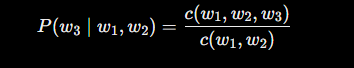

In [19]:
from collections import defaultdict
import numpy as np


class TrigramLanguageModel:
    def __init__(self, bigram_model):
        self.bigram_model = bigram_model

        self.context_counts = defaultdict(int)
        self.trigram_counts = defaultdict(
            lambda: defaultdict(int)
        )

    def fit(self, tokens):
        for w1, w2, w3 in zip(
            tokens[:-2],
            tokens[1:-1],
            tokens[2:]
        ):
            context = (w1, w2)

            self.context_counts[context] += 1
            self.trigram_counts[context][w3] += 1

    def prob(self, w1, w2, w3, alpha=0.01):
        context = (w1, w2)

        if self.trigram_counts[context][w3] > 0:
            return (
                self.trigram_counts[context][w3]
                / self.context_counts[context]
            )

        return self.bigram_model.prob(w2, w3, alpha)
    def generate(self, start_words, length=30, temperature=1.0):
        w1, w2 = start_words

        result = [w1, w2]

        for _ in range(length - 2):
            context = (w1, w2)

            # Если такой контекст есть в триграммах
            if context in self.trigram_counts:
                next_words = list(
                    self.trigram_counts[context].keys()
                )

                probabilities = np.array([
                    self.trigram_counts[context][word]
                    / self.context_counts[context]
                    for word in next_words
                ])

            # Иначе откатываемся на биграмму
            else:
                if w2 not in self.bigram_model.bigram_counts:
                    break

                next_words = list(
                    self.bigram_model.bigram_counts[w2].keys()
                )

                probabilities = np.array([
                    self.bigram_model.prob(w2, word)
                    for word in next_words
                ])

            # Температура
            probabilities = probabilities ** (1 / temperature)
            probabilities = probabilities / probabilities.sum()

            # Выбираем следующее слово
            w3 = np.random.choice(
                next_words,
                p=probabilities
            )

            result.append(w3)

            # Сдвигаем контекст
            w1 = w2
            w2 = w3

        return " ".join(result)
    def perplexity(self, tokens, alpha=0.01):
        total_logprob = 0.0

        for w1, w2, w3 in zip(
            tokens[:-2],
            tokens[1:-1],
            tokens[2:]
        ):
            p = self.prob(
                w1,
                w2,
                w3,
                alpha=alpha
            )

            total_logprob += np.log(p)

        N = len(tokens) - 2

        return np.exp(-total_logprob / N)

In [20]:
trigram_model = TrigramLanguageModel(model)

trigram_model.fit(train_tokens)

In [21]:
context = ("молодой", "человек")

print("Контекст встретился:", trigram_model.context_counts[context], "раз")
print("Продолжения:")
print(dict(trigram_model.trigram_counts[context]))

Контекст встретился: 35 раз
Продолжения:
{'вышел': 1, 'проходя': 1, 'вдруг': 1, 'был': 1, 'переступил': 1, 'взглянул': 1, 'с': 2, 'ни': 1, 'ваша': 1, 'взял': 1, 'оставшись': 1, 'спорить': 1, 'несколько': 1, 'отчасти': 1, 'случалось': 1, 'можете': 1, 'не': 2, 'подтвердил': 1, 'продолжал': 1, 'видел': 1, 'поспешил': 1, 'конечно': 1, 'смотрите': 1, 'и': 2, 'лет': 1, 'что': 1, 'имеющий': 1, 'как': 1, 'очень': 1, 'воскликнула': 1, 'свидригайлов': 1, 'может': 1}


In [22]:
start_pairs = [
    ("молодой", "человек"),
    ("родион", "романович"),
    ("он", "не"),
    ("в", "эту"),
    ("и", "вдруг"),
    ("ниссан", "скайлан")
]

for pair in start_pairs:
    print(f"\nСтарт: {pair}")
    print(
        trigram_model.generate(
            pair,
            length=30
        )
    )


Старт: ('молодой', 'человек')
молодой человек смотрите видите как дверь отстает если дергать ну значит она не сошла с ума но кто знает может быть неправда но вы конечно авдотья романовна была замечательно хороша

Старт: ('родион', 'романович')
родион романович ведь так настаивал свидригайлов с улыбкой вам все время как он вас истязал где что раскольников опять интересуясь финансовой частью дела о на самой простейшей с и это

Старт: ('он', 'не')
он не любил был он очень долго дня два сряду про прусскую палату господ говорил потому что время дорого и может быть а что что вы это порфирий петрович как

Старт: ('в', 'эту')
в эту действительно великолепную панораму и каждый раз почти удивляться одному неясному и неразрешимому своему впечатлению необъяснимым холодом веяло на него вдруг почему то что в сущности прав на вспоможение

Старт: ('и', 'вдруг')
и вдруг он побледнел и закусил губу слушайте сударь меня начал он вынимая из узла довольно хорошенькую но в то же как же ты сам его объясняеш

In [23]:
alpha = 0.01

bigram_ppl = model.perplexity(
    test_tokens,
    alpha=alpha
)

trigram_ppl = trigram_model.perplexity(
    test_tokens,
    alpha=alpha
)

print(f"Bigram perplexity:  {bigram_ppl:.2f}")
print(f"Trigram perplexity: {trigram_ppl:.2f}")

Bigram perplexity:  4118.58
Trigram perplexity: 3395.89


In [24]:
print("BIGRAM:")
print(
    model.generate(
        "молодой",
        length=30,
        temperature=1
    )
)

BIGRAM:
молодой человек посовестился бы кончил и лениво но кто ж она и не встречала сверкающие диким и оставила ан совсем почти восторженно что уж и никого не выдержит господину а


In [25]:
print("\nTRIGRAM:")
print(
    trigram_model.generate(
        ("молодой", "человек"),
        length=30,
        temperature=1
    )
)


TRIGRAM:
молодой человек очень уж я и сам своими собственными руками отдал этот сторублевый билет софье семеновне все это значит с минуту один подле другого и не шевельнулся сон это продолжается


### Результаты сравнения

На отложенной тестовой части корпуса получены следующие значения:

| Модель | Perplexity |
|---|---:|
| Биграммная | 4118.58 |
| Триграммная с backoff | **3395.89** |

Триграммная модель показала меньшую perplexity, следовательно,
она лучше предсказывает последовательность слов на тестовой выборке.

Улучшение связано с использованием более широкого контекста:
триграммная модель учитывает два предыдущих слова вместо одного.
При отсутствии конкретной триграммы выполняется откат на
биграммную модель, что позволяет обрабатывать ранее не встречавшиеся
трёхсловные последовательности.

# БОНУС 2.

In [26]:
import torch
import math

from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen3-0.6B-Base"

device = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("device:", device)

qwen_tok = AutoTokenizer.from_pretrained(MODEL_ID)

qwen_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32
)

qwen_model = qwen_model.to(device).eval()

d:\Coding\Anaconda\envs\YOLO\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
d:\Coding\Anaconda\envs\YOLO\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vadim\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
d:\Coding\Anaconda\envs\YOLO\Lib\site-packages\huggingface_hub\file_download.py:149:

In [27]:
@torch.no_grad()
def qwen_log_likelihood(text):
    ids = qwen_tok(
        text,
        return_tensors="pt"
    ).to(device)["input_ids"]

    logits = qwen_model(ids).logits[0, :-1].float()

    logp = torch.log_softmax(
        logits,
        dim=-1
    )

    target = ids[0, 1:]

    token_logp = logp[
        torch.arange(target.numel(), device=device),
        target
    ].cpu()

    return token_logp.sum().item(), token_logp.numel()

In [28]:
qwen_connected, n_connected = qwen_log_likelihood(
    test_sentence
)

qwen_shuffled, n_shuffled = qwen_log_likelihood(
    shuffled_sentence
)

print("Связный текст:")
print(test_sentence)
print(f"log P = {qwen_connected:.2f}")

print("\nПеремешанный текст:")
print(shuffled_sentence)
print(f"log P = {qwen_shuffled:.2f}")

Связный текст:
он скорее умрет чем отпустит ее и и уж конечно она убьет его теперь в
log P = -101.33

Перемешанный текст:
его уж ее скорее отпустит он конечно убьет она в и умрет чем теперь и
log P = -117.66


In [29]:
bigram_connected = model.logprob(
    test_sentence,
    alpha=1
)

bigram_shuffled = model.logprob(
    shuffled_sentence,
    alpha=1
)

bigram_gap = bigram_connected - bigram_shuffled
qwen_gap = qwen_connected - qwen_shuffled

print("Разница между связным и перемешанным текстом:")
print(f"Bigram: {bigram_gap:.2f}")
print(f"Qwen:   {qwen_gap:.2f}")

Разница между связным и перемешанным текстом:
Bigram: 10.71
Qwen:   16.32


### Сравнение с Qwen3-0.6B-Base

Для связного и перемешанного вариантов одного и того же текста
были рассчитаны значения log-probability.

Разница между log-probability связного и перемешанного текста:

| Модель | Разница log P |
|---|---:|
| Биграммная | 10.71 |
| Qwen3-0.6B-Base | **16.32** |

Обе модели присваивают более высокую вероятность связному тексту.
Однако у Qwen3-0.6B-Base разрыв между связным и перемешанным
вариантами больше примерно в 1.52 раза.

Это показывает, что Qwen лучше учитывает порядок слов и более широкий
контекст. Биграммная модель использует только одно предыдущее слово,
тогда как Qwen учитывает всю предшествующую последовательность токенов.

Абсолютные значения log-probability двух моделей напрямую
сравнивать некорректно, поскольку биграммная модель работает со
словами, а Qwen — с токенами собственного токенизатора. Поэтому
сравнивается разница между связным и перемешанным текстом внутри
каждой модели.

# БОНУС 3


In [30]:
with open(
    "010000_000060_ART-8f382c81-78f9-4575-bf21-4cfcd2439626-Преступление_и_наказание_tokens.txt",
    "r",
    encoding="utf-8"
) as f:
    dostoevsky_tokens = f.read().split()

with open(
    "Анна_Каренина_(Толстой)_tokens.txt",
    "r",
    encoding="utf-8"
) as f:
    tolstoy_tokens = f.read().split()

print("Достоевский:", len(dostoevsky_tokens))
print("Толстой:", len(tolstoy_tokens))

Достоевский: 173138
Толстой: 271303


In [31]:
def train_test_split(tokens, train_ratio=0.9):
    split_idx = int(len(tokens) * train_ratio)

    train = tokens[:split_idx]
    test = tokens[split_idx:]

    return train, test

In [32]:
dost_train, dost_test = train_test_split(dostoevsky_tokens)
tolstoy_train, tolstoy_test = train_test_split(tolstoy_tokens)

print("Достоевский:")
print("train:", len(dost_train))
print("test:", len(dost_test))

print("\nТолстой:")
print("train:", len(tolstoy_train))
print("test:", len(tolstoy_test))

Достоевский:
train: 155824
test: 17314

Толстой:
train: 244172
test: 27131


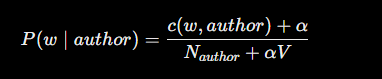

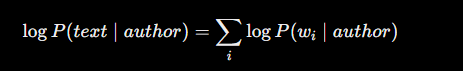

In [35]:
from collections import defaultdict
import numpy as np


class NaiveBayesAuthorClassifier:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

        self.word_counts = {
            "dostoevsky": defaultdict(int),
            "tolstoy": defaultdict(int)
        }

        self.total_words = {
            "dostoevsky": 0,
            "tolstoy": 0
        }

        self.vocabulary = set()

    def fit(self, dost_tokens, tolstoy_tokens):
        for word in dost_tokens:
            self.word_counts["dostoevsky"][word] += 1
            self.total_words["dostoevsky"] += 1
            self.vocabulary.add(word)

        for word in tolstoy_tokens:
            self.word_counts["tolstoy"][word] += 1
            self.total_words["tolstoy"] += 1
            self.vocabulary.add(word)

    def word_prob(self, word, author):
        V = len(self.vocabulary)

        return (
            self.word_counts[author][word] + self.alpha
        ) / (
            self.total_words[author] + self.alpha * V
        )

    def score(self, tokens, author):
        total_logprob = 0.0

        for word in tokens:
            p = self.word_prob(word, author)
            total_logprob += np.log(p)

        return total_logprob

    def predict(self, tokens):
        dost_score = self.score(
            tokens,
            "dostoevsky"
        )

        tolstoy_score = self.score(
            tokens,
            "tolstoy"
        )

        if dost_score > tolstoy_score:
            return "Достоевский"

        return "Толстой"

In [36]:
author_model = NaiveBayesAuthorClassifier(
    alpha=1.0
)

author_model.fit(
    dost_train,
    tolstoy_train
)

In [37]:
fragment = dost_test[100:130]

print(" ".join(fragment))

print(
    author_model.predict(fragment)
)

решимостью воспаленно страстным тяжелым взглядом дуня поняла что он скорее умрет чем отпустит ее и и уж конечно она убьет его теперь в двух шагах вдруг она отбросила револьвер бросила
Достоевский


In [38]:
fragment = tolstoy_test[100:130]

print(" ".join(fragment))

print(
    author_model.predict(fragment)
)

не мог всего обнять слушая графиню лидию ивановну и чувствуя устремленные на себя красивые наивные или плутовские он сам не знал глаза landau степан аркадьич начинал испытывать какую то особенную
Толстой


In [39]:
def make_fragments(tokens, fragment_size=30):
    fragments = []

    for i in range(0, len(tokens) - fragment_size + 1, fragment_size):
        fragment = tokens[i:i + fragment_size]
        fragments.append(fragment)

    return fragments

In [40]:
dost_fragments = make_fragments(
    dost_test,
    fragment_size=30
)

tolstoy_fragments = make_fragments(
    tolstoy_test,
    fragment_size=30
)

print("Фрагментов Достоевского:", len(dost_fragments))
print("Фрагментов Толстого:", len(tolstoy_fragments))

Фрагментов Достоевского: 577
Фрагментов Толстого: 904


In [41]:
correct = 0
total = 0

for fragment in dost_fragments:
    prediction = author_model.predict(fragment)

    if prediction == "Достоевский":
        correct += 1

    total += 1


for fragment in tolstoy_fragments:
    prediction = author_model.predict(fragment)

    if prediction == "Толстой":
        correct += 1

    total += 1


accuracy = correct / total

print("Правильно:", correct)
print("Всего:", total)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Правильно: 1350
Всего: 1481
Accuracy: 0.9115
Accuracy: 91.15%


In [43]:
dost_correct = 0

for fragment in dost_fragments:
    if author_model.predict(fragment) == "Достоевский":
        dost_correct += 1


tolstoy_correct = 0

for fragment in tolstoy_fragments:
    if author_model.predict(fragment) == "Толстой":
        tolstoy_correct += 1


dost_accuracy = dost_correct / len(dost_fragments)
tolstoy_accuracy = tolstoy_correct / len(tolstoy_fragments)

print(
    f"Достоевский: {dost_accuracy * 100:.2f}%"
)

print(
    f"Толстой: {tolstoy_accuracy * 100:.2f}%"
)

Достоевский: 86.66%
Толстой: 94.03%


In [44]:
confusion = {
    "Достоевский": {
        "Достоевский": 0,
        "Толстой": 0
    },
    "Толстой": {
        "Достоевский": 0,
        "Толстой": 0
    }
}

for fragment in dost_fragments:
    pred = author_model.predict(fragment)

    confusion["Достоевский"][pred] += 1


for fragment in tolstoy_fragments:
    pred = author_model.predict(fragment)

    confusion["Толстой"][pred] += 1


print("Настоящий \\ Предсказанный")
print()

print(
    "Достоевский:",
    confusion["Достоевский"]
)

print(
    "Толстой:",
    confusion["Толстой"]
)

Настоящий \ Предсказанный

Достоевский: {'Достоевский': 500, 'Толстой': 77}
Толстой: {'Достоевский': 54, 'Толстой': 850}
